<a href="https://colab.research.google.com/github/Sayak-coder/SIH_26086/blob/main/weekly_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow

In [2]:
!pip install --upgrade xee

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.8 MB/s eta 0:00:00


In [3]:
!pip install -u geemap


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -u


In [4]:
!pip install xee

In [5]:
import ee
import geemap
import xarray as xr
from xee import helpers
import shapely.geometry
import torch
from sklearn.preprocessing import StandardScaler
import tensorflow

In [6]:
ee.Authenticate()
ee.Initialize(
    project='gen-lang-client-0960220624',
    opt_url='https://earthengine-highvolume.googleapis.com'
)

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


In [7]:
map=geemap.Map()
map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [40]:
roi=map.draw_last_feature.geometry()
roi

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "Feature.geometry",
    "arguments": {
      "feature": {
        "functionInvocationValue": {
          "functionName": "Feature",
          "arguments": {
            "geometry": {
              "functionInvocationValue": {
                "functionName": "GeometryConstructors.Polygon",
                "arguments": {
                  "coordinates": {
                    "constantValue": [
                      [
                        [
                          -271.94458,
                          23.900905
                        ],
                        [
                          -271.94458,
                          24.156778
                        ],
                        [
                          -271.61499,
                          24.156778
                        ],
                        [
                          -271.61499,
                          23.900905
                        ],
                        [
                          -271.94458,
                          23.900905
                        ]
                      ]
                    ]
                  },
                  "geodesic": {
                    "constantValue": false
                  }
                }
              }
            }
          }
        }
      }
    }
  }
})

In [41]:
def wrap_lon(lon):
    return ((lon + 180) % 360) - 180

coords = roi.getInfo()['coordinates']
fixed_coords = [[[wrap_lon(lon), lat] for lon, lat in ring] for ring in coords]
roi_fixed = ee.Geometry.Polygon(fixed_coords)
roi_fixed

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "GeometryConstructors.Polygon",
    "arguments": {
      "coordinates": {
        "constantValue": [
          [
            [
              88.05542000000003,
              23.900905
            ],
            [
              88.05542000000003,
              24.156778
            ],
            [
              88.38501000000002,
              24.156778
            ],
            [
              88.38501000000002,
              23.900905
            ],
            [
              88.05542000000003,
              23.900905
            ]
          ]
        ]
      },
      "evenOdd": {
        "constantValue": true
      }
    }
  }
})

In [42]:
start_time=ee.Date('2020')
end_time=ee.Date('2026')
time_diff=end_time.difference(start_time,'week')
time_diff

In [43]:
end_date = start_time.advance(1, 'week')
end_date

In [44]:
time_list = ee.List.sequence(0, ee.Number(time_diff).subtract(1)).map(
    lambda x: start_time.advance(x, 'week')
)
time_list

In [45]:
time_list = ee.List.sequence(0, ee.Number(time_diff).subtract(1)).map(
    lambda x: start_time.advance(x, 'week')
)

def daily(date, col, bands):
    d = ee.Date(date)
    blank = ee.Image.constant(ee.List.repeat(0, len(bands))).rename(bands).selfMask()
    img = col.filterDate(d, d.advance(1, 'week')).merge(ee.ImageCollection([blank])).mean()
    return img.set('system:time_start', d.millis())

pr = (
    ee.ImageCollection("UCSB-CHC/CHIRPS/V3/DAILY_RNL")
    .filterDate(start_time, end_time)
    .select(['precipitation'],['pr'])
)

veg = (
    ee.ImageCollection("MODIS/061/MOD13Q1")
    .filterDate(start_time,end_time)
    .select(['NDVI','EVI'],['ndvi','evi'])
)

temp=(
    ee.ImageCollection("MODIS/061/MOD11A1")
    .filterDate(start_time,end_time)
    .select(['LST_Day_1km','LST_Night_1km'],['dayT','nightT'])
)

et=(
    ee.ImageCollection("MODIS/061/MOD16A2")
    .filterDate(start_time,end_time)
    .select(['ET'],['et'])
)

pr_daily=ee.ImageCollection(
    time_list.map(
        lambda x:daily(x, pr,['pr'])
    )
)

veg_daily=ee.ImageCollection(
    time_list.map(
        lambda x:daily(x, veg,['ndvi','evi'])
    )
)

temp_daily=ee.ImageCollection(
    time_list.map(
        lambda x:daily(x, temp,['dayT','nightT'])
    )
)

et_daily=ee.ImageCollection(
    time_list.map(
        lambda x:daily(x, et,['et'])
    )
)


In [46]:
landcover=(
    ee.ImageCollection("MODIS/061/MCD12Q1").filterDate(start_time,end_time).mode().select(['LC_Type1'],['lc'])
)

topography=(
    ee.Image("USGS/GTOPO30").rename('dem')
)

In [47]:
landcover

In [48]:
# collection=temp_daily.combine(veg_daily).combine(et_daily).combine(pr_daily).map(
collection=temp_daily.combine(et_daily).combine(pr_daily).map(
    lambda x: x.addBands(landcover).addBands(topography)
)
collection

In [49]:
# roi_fixed is an ee.Geometry — convert it to GeoJSON, then to shapely
geojson_roi_fixed = roi_fixed.getInfo()
shapely_roi = shapely.geometry.shape(geojson_roi_fixed)

grid = helpers.fit_geometry(
    geometry=shapely_roi,
    grid_crs='EPSG:4326',
    grid_scale=(0.1, -0.1)
)
ds = xr.open_dataset(collection, engine='ee', **grid)

In [50]:
ds10km=ds

In [51]:
ds10km=ds10km.sortby('time')*1

In [52]:
ds10km

<xarray.Dataset> Size: 93kB
Dimensions:  (time: 313, y: 3, x: 4)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2020-01-01 2020-01-08 ... 2025-12-24
  * y        (y) float64 24B 24.15 24.05 23.95
  * x        (x) float64 32B 88.05 88.15 88.25 88.35
Data variables:
    dayT     (time, y, x) float32 15kB 1.474e+04 1.47e+04 ... 1.454e+04
    nightT   (time, y, x) float32 15kB 1.426e+04 1.427e+04 ... 1.421e+04
    et       (time, y, x) float32 15kB nan nan nan nan ... 36.0 39.0 52.0 59.0
    pr       (time, y, x) float32 15kB 4.496 4.185 3.458 ... 0.05152 0.03675
    lc       (time, y, x) float32 15kB 12.0 12.0 12.0 12.0 ... 12.0 12.0 12.0
    dem      (time, y, x) float32 15kB 22.0 23.0 17.0 19.0 ... 18.0 20.0 13.0

In [53]:
ds10km=ds10km.to_dataframe().dropna()

In [54]:
ds10km

dayT        nightT     et        pr    lc  \
time       y     x                                                          
2020-12-30 24.15 88.05  14922.000000  14242.500000   78.0  0.136407  12.0   
                 88.15  14867.799805  14261.666992   78.0  0.125067  12.0   
                 88.25  14794.799805  14281.333008   87.0  0.103715  12.0   
                 88.35  14779.799805  14233.666992  101.0  0.112914  12.0   
           24.05 88.05  14818.200195  14275.000000   80.0  0.072585  12.0   
...                              ...           ...    ...       ...   ...   
2025-12-24 24.05 88.35  14554.000000  14258.200195   61.0  0.061493  12.0   
           23.95 88.05  14551.000000  14290.400391   36.0  0.038842  12.0   
                 88.15  14550.000000  14286.799805   39.0  0.037678  12.0   
                 88.25  14548.000000  14290.799805   52.0  0.051521  12.0   
                 88.35  14538.000000  14207.799805   59.0  0.036752  12.0   

                         dem  
time       y     x            
2020-12-30 24.15 88.05  22.0  
                 88.15  23.0  
                 88.25  17.0  
                 88.35  19.0  
           24.05 88.05  19.0  
...                      ...  
2025-12-24 24.05 88.35  23.0  
           23.95 88.05  23.0  
                 88.15  18.0  
                 88.25  20.0  
                 88.35  13.0  

[1954 rows x 6 columns]

In [55]:
X10km=ds10km.drop('pr',axis=1)
y10km=ds10km['pr']

In [56]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X10km,y10km,test_size=0.2,random_state=45)

In [57]:
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

y_train=scaler.fit_transform(y_train.values.reshape(-1,1))
y_test=scaler.transform(y_test.values.reshape(-1,1))

In [58]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [59]:
model=Sequential()
model.add(Dense(64,activation='relu',input_dim=X_train.shape[1]))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='relu'))
model.compile(
    loss='mse',
    optimizer='adam',
    metrics=['mae']
)

In [60]:
from re import VERBOSE
model.fit(
    X_train,y_train,epochs=20,batch_size=8,validation_split=0.2,verbose=1
)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.8176 - mae: 0.6557 - val_loss: 0.9110 - val_mae: 0.6758
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7655 - mae: 0.6514 - val_loss: 0.8912 - val_mae: 0.6823
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7466 - mae: 0.6414 - val_loss: 0.8871 - val_mae: 0.6698
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7457 - mae: 0.6452 - val_loss: 0.8930 - val_mae: 0.6632
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7460 - mae: 0.6513 - val_loss: 0.8854 - val_mae: 0.6771
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7431 - mae: 0.6491 - val_loss: 0.8858 - val_mae: 0.6717
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7285 - mae: 0.6399 - val_loss: 0.8882 - val_mae: 0.6692
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7282 - mae: 0.6448 - val_loss: 0.8996 - val_mae: 0.6598
Epoch 9/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

In [61]:
model_evaluation=model.evaluate(X_test,y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7996 - mae: 0.6837 


In [62]:
geojson_roi_fixed = roi_fixed.getInfo()
shapely_roi = shapely.geometry.shape(geojson_roi_fixed)

grid = helpers.fit_geometry(
    geometry=shapely_roi,
    grid_crs='EPSG:4326',
    grid_scale=(0.01, -0.01)
)
ds1km = xr.open_dataset(collection, engine='ee', **grid)

In [63]:
ds1km

<xarray.Dataset> Size: 7MB
Dimensions:  (time: 313, y: 26, x: 34)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2020-01-01 2020-01-08 ... 2021-11-24
  * y        (y) float64 208B 24.16 24.14 24.14 24.12 ... 23.93 23.92 23.91
  * x        (x) float64 272B 88.05 88.06 88.07 88.08 ... 88.36 88.37 88.38
Data variables:
    dayT     (time, y, x) float32 1MB ...
    nightT   (time, y, x) float32 1MB ...
    et       (time, y, x) float32 1MB ...
    pr       (time, y, x) float32 1MB ...
    lc       (time, y, x) float32 1MB ...
    dem      (time, y, x) float32 1MB ...

In [64]:
ds1km=ds1km.to_dataframe().dropna()

In [65]:
X1km=ds1km.drop('pr',axis=1)
y1km=ds1km['pr']

In [66]:
X1km_scale=StandardScaler()
y1km_scale=StandardScaler()

X1km_scaled=X1km_scale.fit_transform(X1km)
y1km_scaled=y1km_scale.fit_transform(y1km.values.reshape(-1,1))

In [67]:
ds1km['pr1km']=y1km_scale.inverse_transform(model.predict(X1km_scaled))

4081/4081 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step


In [68]:
result=ds1km[['pr','pr1km']].to_xarray().sortby(['time','x','y'])

In [69]:
result_sub=result.sel(time='2024')

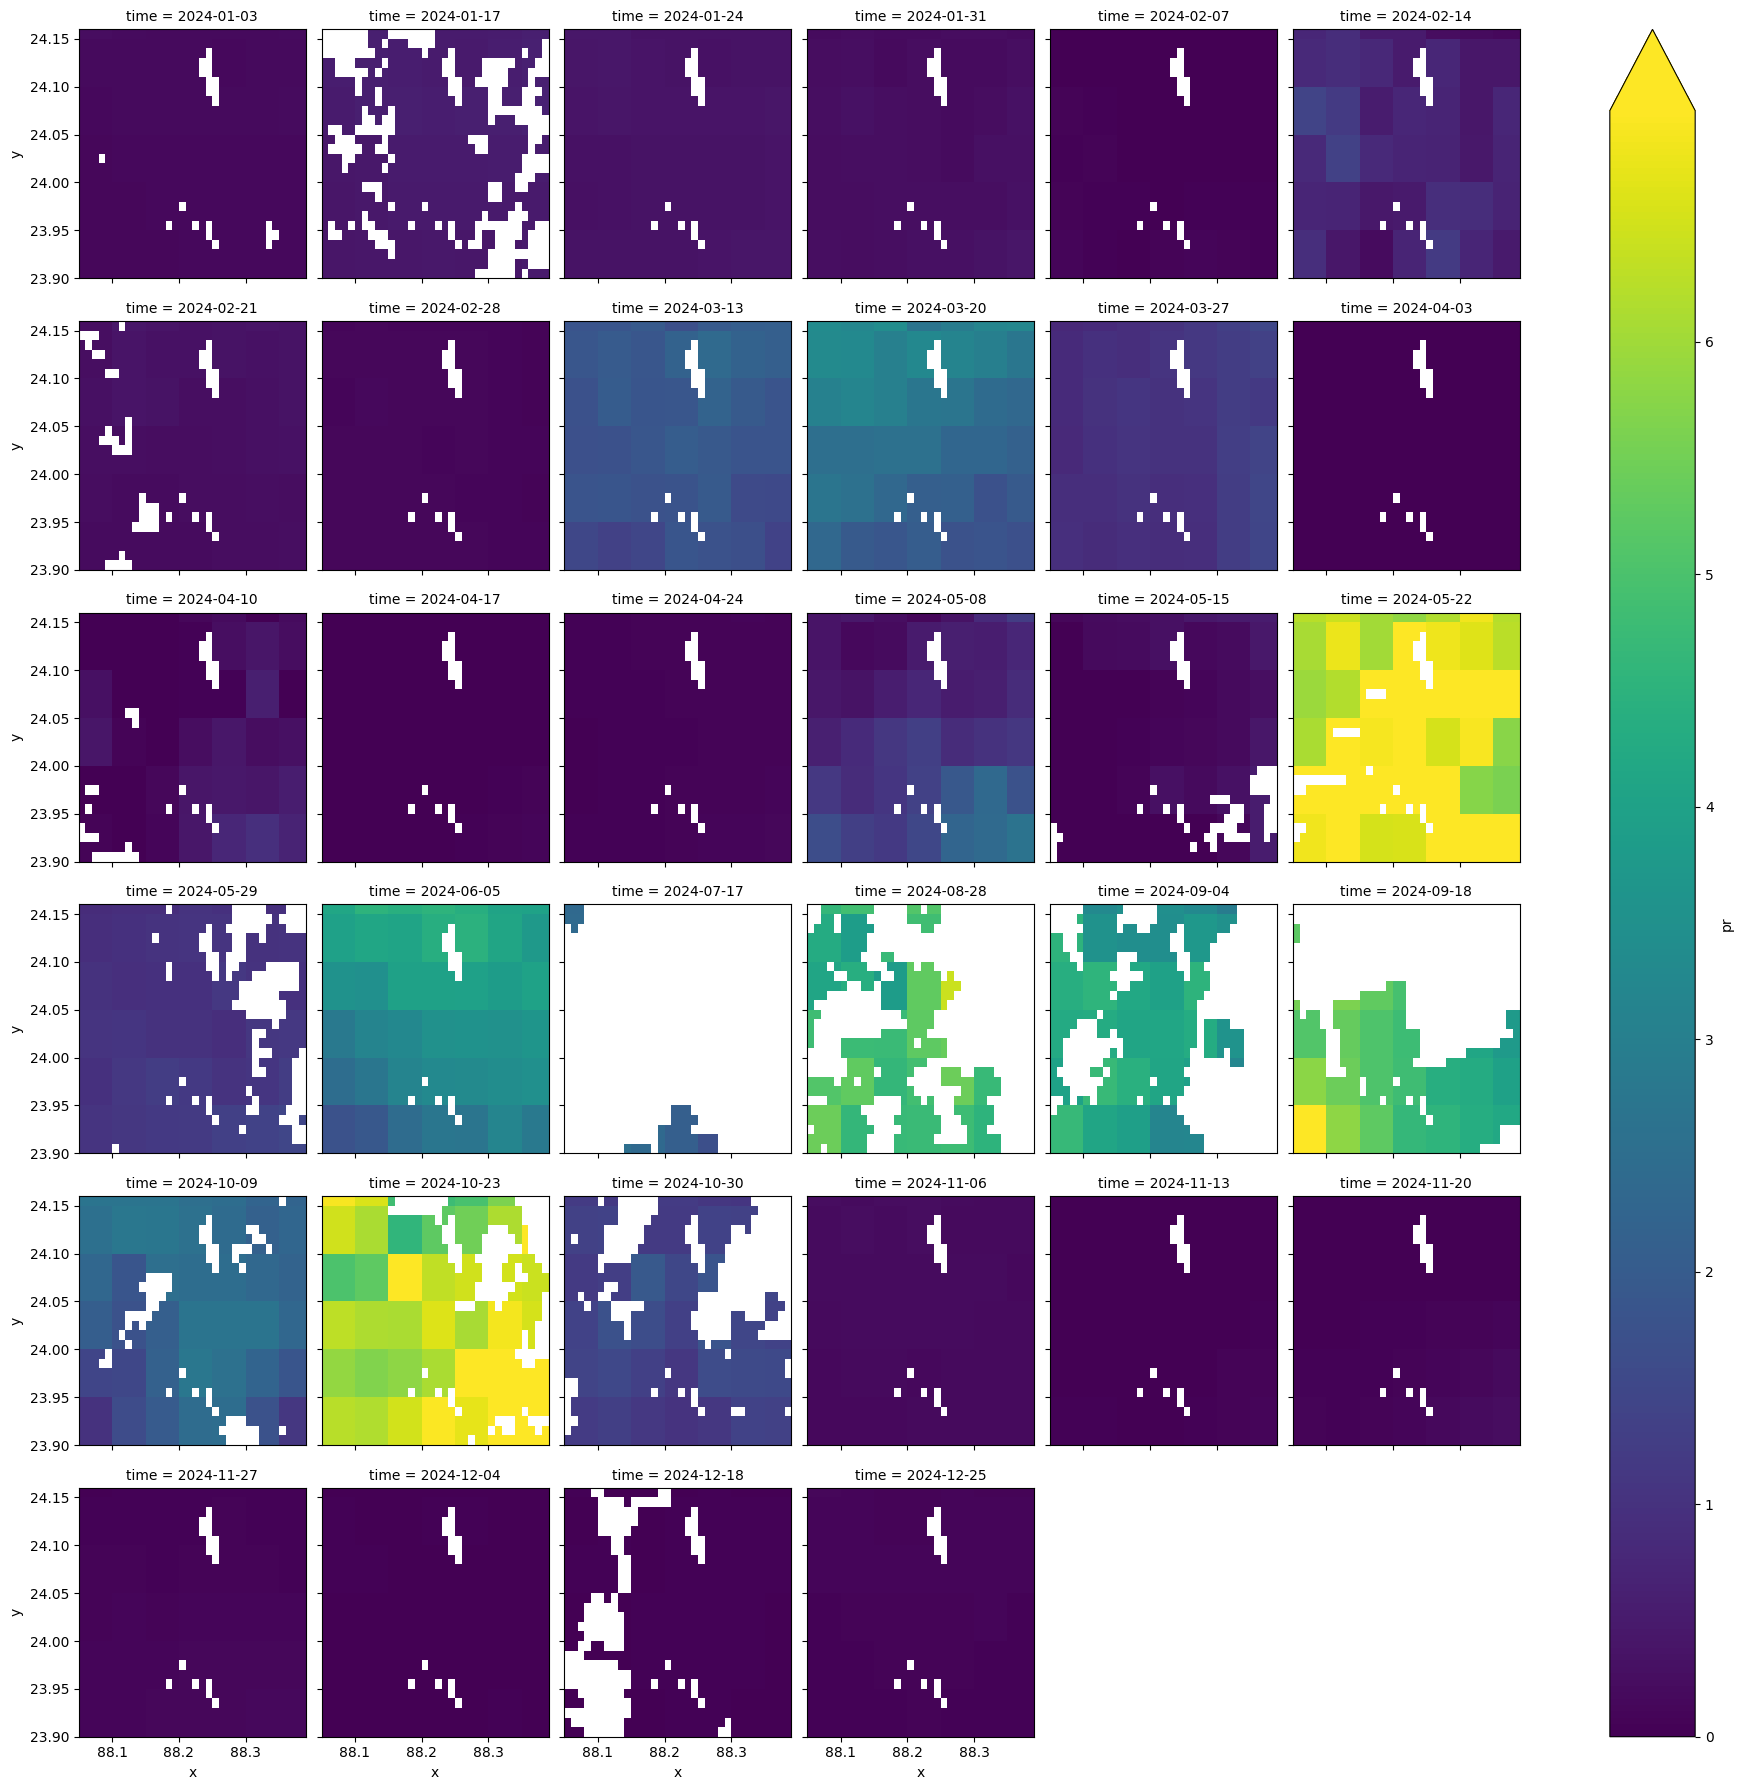

In [70]:
result_sub.pr.plot(
    x='x',y='y',col='time',robust = True, col_wrap = 6
)

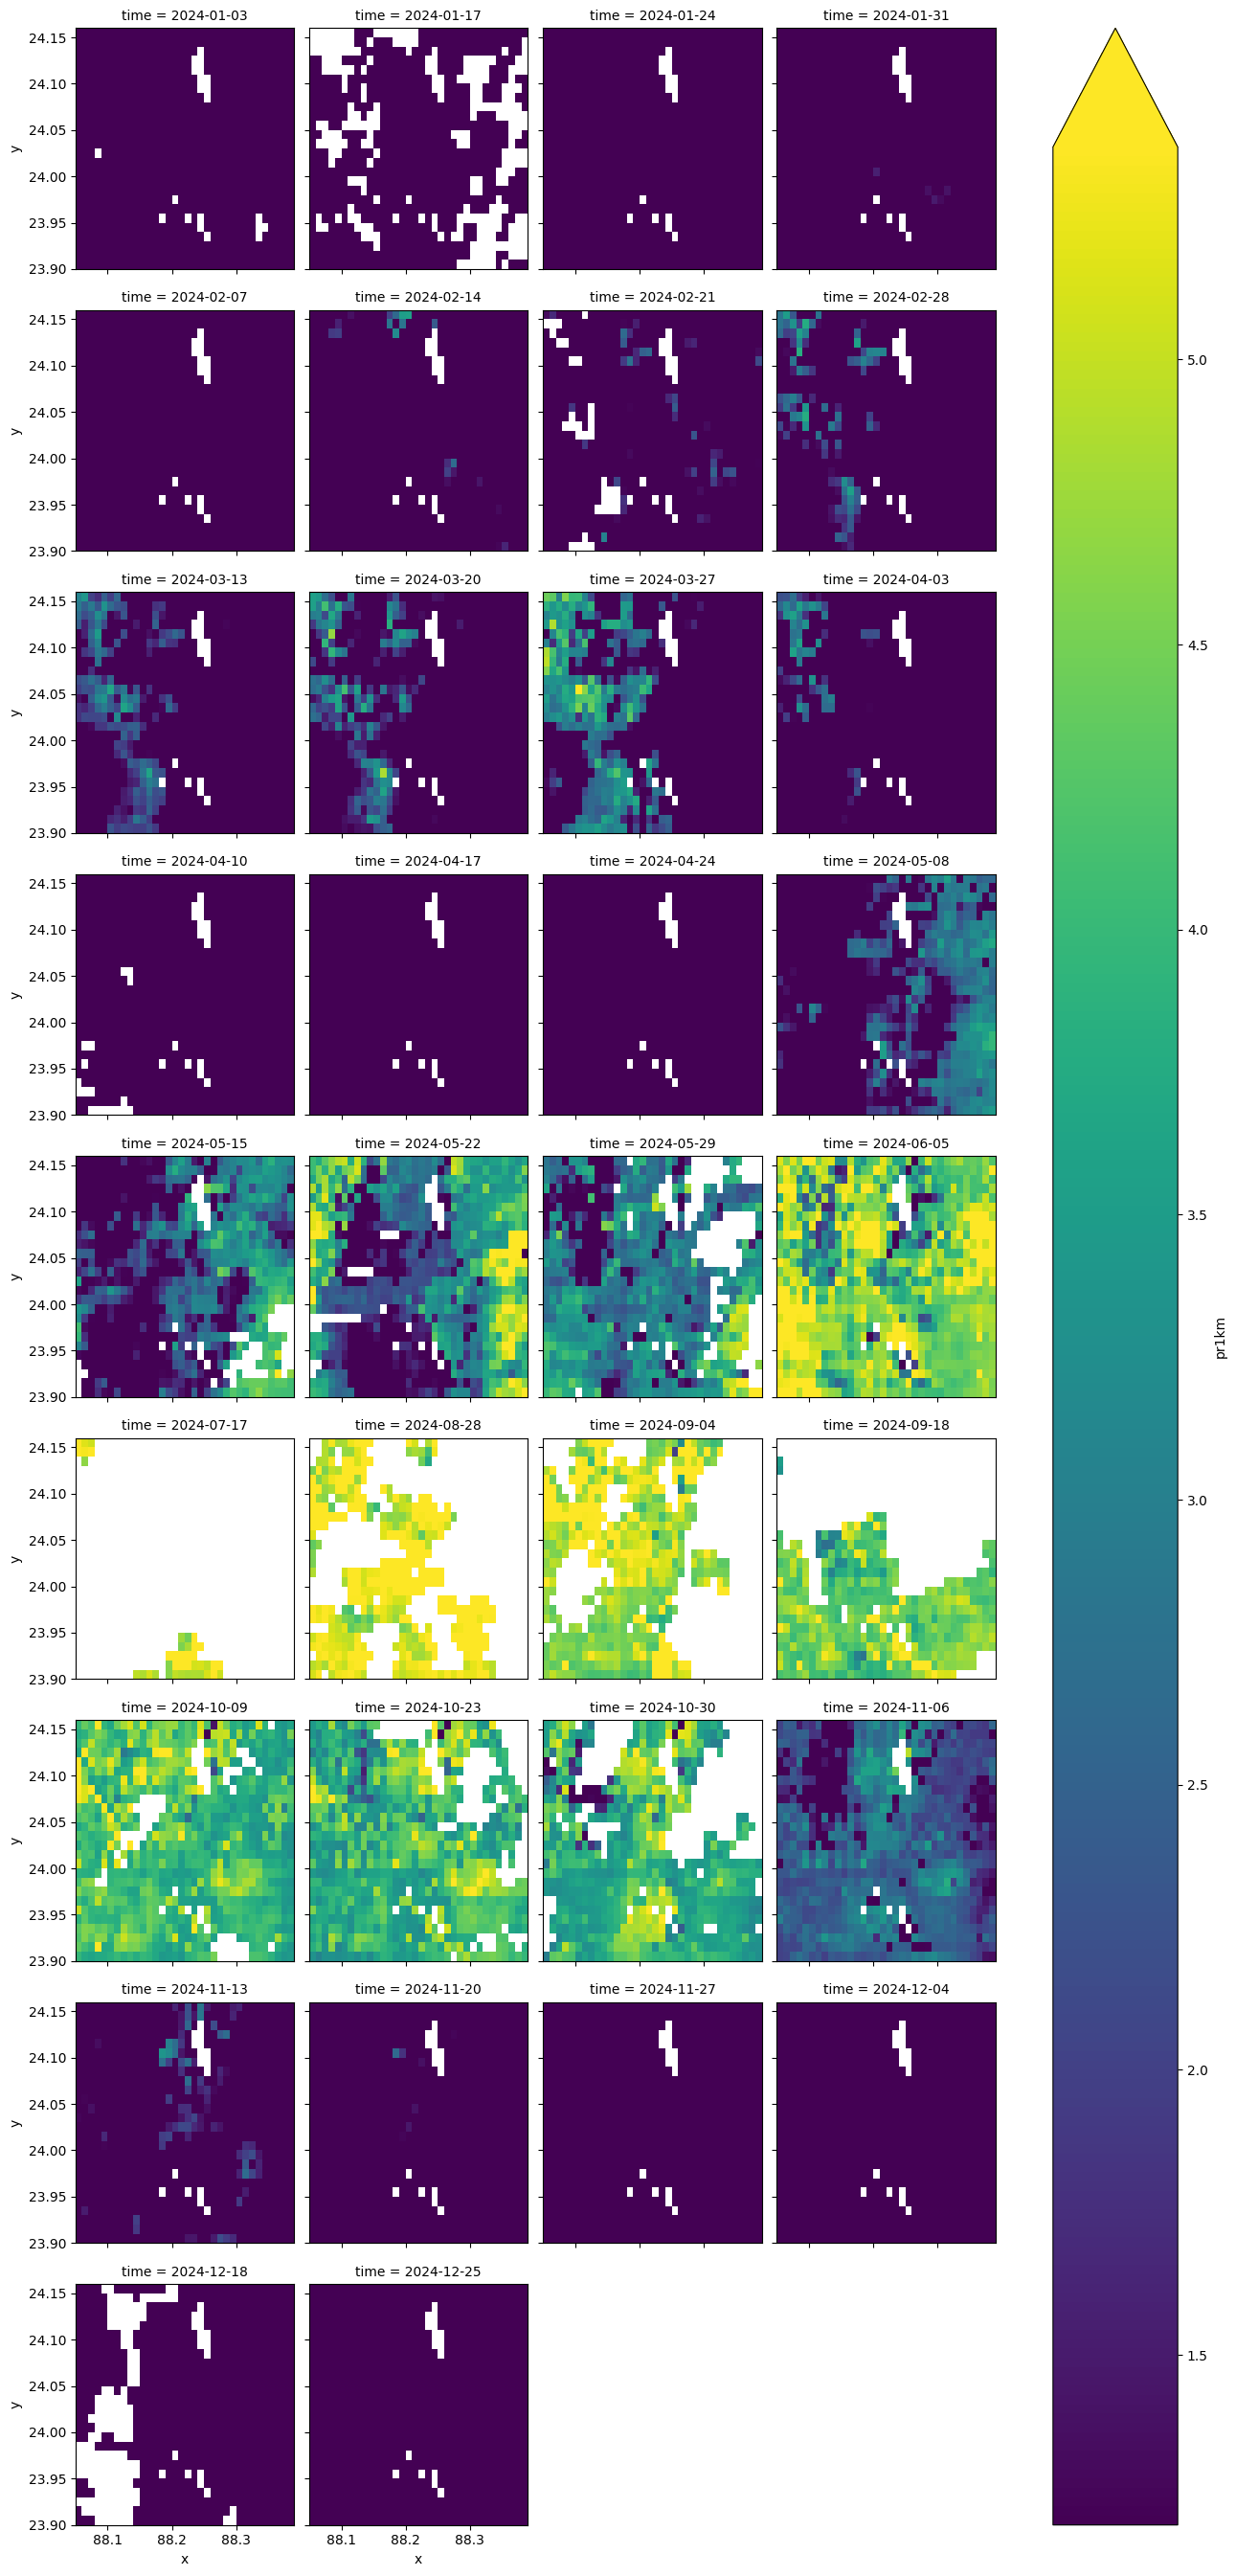

In [76]:
result_sub.pr1km.plot(
    x='x',y='y',col='time',robust = True, col_wrap = 4
)